In [1]:
%load_ext autoreload
%autoreload 2
 
import sys, pathlib, json, pprint, pandas as pd 
from pathlib import Path
from pydantic import Field,BaseModel 
sys.path.append('../../')
sys.path.append('../')
sys.path.append('./')

from runtime.v4.semantics.load_semantics import load_semantics
from runtime.v4.semantics.semantic_models import * 
from runtime.v4.analyst_agent.catalog import Catalog
from runtime.v4.analyst_agent.smart_data import SmartData
from runtime.v4.analyst_agent.smart_data_tools  import SmartDataTools

import  os  
from datetime import datetime 
from langchain_core.tools import StructuredTool, Tool


import duckdb
from typing import Any, Dict, List, Iterable, Union, Optional 
import yaml
import pprint
import pandas as pd, numpy as np
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.runnables import RunnableConfig, Runnable, RunnableLambda
 
from langchain.tools import tool, ToolRuntime
from langgraph.runtime import get_runtime 
from langchain.agents import create_agent
from langchain_core.runnables import RunnableLambda
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.runnables import RunnableConfig
from langchain_core.runnables import Runnable
from langchain.tools import tool, ToolRuntime
from langgraph.runtime import get_runtime 
from langchain.agents import create_agent
 

In [2]:
inj = pd.read_csv("../datasets/IX5I_4P/injectors.csv")
inj['DATE'] = pd.to_datetime( inj['DATE'],dayfirst=True)
inj['DAY']   = inj['DATE'].dt.day
inj['MONTH'] = inj['DATE'].dt.month
inj['YEAR']  = inj['DATE'].dt.year
pinj = pd.read_csv("../datasets/IX5I_4P/producers.csv")
pinj['DATE'] = pd.to_datetime( pinj['DATE'],dayfirst=True)
pinj['DAY']   = pinj['DATE'].dt.day
pinj['MONTH'] = pinj['DATE'].dt.month
pinj['YEAR']  = pinj['DATE'].dt.year
locs= pd.read_csv("../datasets/IX5I_4P/locations.csv")
 
from get_llm_model import azure_llm_if
from support import * 

imported


In [3]:

semantics_json = Path('../runtime/v4/semantics/semantic_models.json')
semantic_catalog = load_semantics(semantics_json)
known_table_models = { t.name: t for t in semantic_catalog.tables } 

df_dict = {'injectors': inj, 'producers':pinj , 'locations': locs }

data = SmartData()
data.initialize_from_named_dataframes( df_dict, known_table_models)

smart_data_tools = SmartDataTools( data=data)
tools = smart_data_tools.get_tools(include_planning_tools=False)

print(smart_data_tools.catalog_snapshot())




------------------------------------------------------------

Table: injectors
  description: Injector water injection time series.
  kind: base
  row_count: 490
  Columns:
    - name: DATE | data_type: timestamp | description: Injection date. | derived_column: False
    - name: NAME | data_type: string | description: Injector well identifier. | derived_column: False
    - name: WATER_INJECTION_VOLUME | data_type: float | description: Injected water volume. | derived_column: False
    - name: SUBZONE | data_type: string | description: Vertical subzone. | derived_column: False
    - name: SECTOR | data_type: integer | description: Geographic sector. | derived_column: False
    - name: YEAR | data_type: integer | description: Year from DATE. | derived_column: False
    - name: MONTH | data_type: integer | description: Month from DATE. | derived_column: False
    - name: DAY | data_type: integer | description: Day from DATE. | derived_column: False

Table: producers
  description: Produce

In [4]:

llm = azure_llm_if()



planner_prompt = planner_prompt_builder(smart_data_tools)
print(planner_prompt)




You are a SQL agent planner.
Your job is to generate a high-level plan of logical operations to perform 
on the tables of a database to to answer the user questions. 
Use the information available in the catalog as the truth on tables and their schemas.
The plan must be agent-friendly as it will be consumed by an sql agent 

Workflow:
You must:

1. Analyze the user question and the information in the database catalog

2. Refine the user query into an agent-friendly (refined_query) query that highlights the intent (correct typos,etc). 

3. Produce a step-by-step PLAN 
   The PLAN must contain no SQL and no tool calls.

- Only tables and columns explicitly listed in catalog exist.
- Never invent tables or columns.
- The PLAN must include:
    - source tables
    - target table names
    - whether any existing derived tables can be reused
    - execution order
    - one short line of logic per target table
- If multiple output tables are required:
    - those must be generated sequentia

In [27]:
messages = [] 
instruction = query11


messages = [{
    "role": "system",
    "content": planner_prompt
    },
    {
    "role": "user",
    "content": instruction
    }]


plan = llm.invoke(messages).content

print( plan )

Rephrased Query: Create two separate tables: one ranking injector wells by their total water injection volume, and another ranking producer wells by their total oil production volume.

PLAN:

1. **injector_wells_ranked_by_water_injection**
   - Source table: `injectors`
   - Logic: Aggregate the total `water_injection_volume` for each injector well (`name`), then rank the wells in descending order of total water injection volume.

2. **producer_wells_ranked_by_oil_production**
   - Source table: `producers`
   - Logic: Aggregate the total `oil_volume` for each producer well (`name`), then rank the wells in descending order of total oil production volume.


In [28]:


idiom = 'duckdb'
idiom_rules= {'date subtraction': "Use column - INTERVAL 'X days/months'. NEVER use DATE_SUB() or DATEADD().",
 'date truncation': "Use DATE_TRUNC('month', column).",
 'reserved keywords': 'Always wrap the column name "DATE" in double quotes to avoid Binder Errors.',
 'string concatenation': 'Use the || operator or CONCAT().',
 'boolean aggregation': 'Use FILTER clauses or BOOL_OR() / BOOL_AND() for cleaner logic.',
 'nested aggregates': 'Avoid nested aggregates—never wrap MAX/MIN inside SUM/AVG/etc. Example: WITH current_year AS (SELECT EXTRACT(YEAR FROM MAX("DATE")) AS year FROM injectors), yearly_totals AS (...), yoy AS (...) SELECT ... FROM ... WHERE YEAR = (SELECT year FROM current_year)',
 'cte helpers': 'Use CTEs to capture helper scalars (like current_year via MAX("DATE")) before performing group aggregations. For example:\n    WITH current_year AS (SELECT EXTRACT(YEAR FROM MAX("DATE")) AS year FROM injectors),\n         yearly_totals AS (...),\n         yoy AS (...)\n    SELECT ... FROM ... WHERE YEAR = (SELECT year FROM current_year)'
}
executor_prompt = executor_prompt_builder(idiom, idiom_rules,plan)
agent = create_agent(
        model=llm,
        system_prompt=executor_prompt,
        tools=tools,
        #response_format=AgentTableResponse,
        #checkpointer= InMemorySaver() 
    )
 

In [29]:
try:
    response = run_agent_stream_values(agent, {} ) 
    last_response = response 
except Exception as e:
    print("STREAM FAILED:", str(e))




--- AIMessage ---
name: None
TOOL CALL: catalog_snapshot
ARGS: {'input_tables': ['injectors']}
TOOL CALL: catalog_snapshot
ARGS: {'input_tables': ['producers']}

--- ToolMessage ---
name: catalog_snapshot
BASE TABLES
------------------------------------------------------------

Table: injectors
  description: Injector water injection time series.
  kind: base
  row_count: 490
  Columns:
    - name: DATE | data_type: timestamp | description: Injection date. | derived_column: False
    - name: NAME | data_type: string | description: Injector well identifier. | derived_column: False
    - name: WATER_INJECTION_VOLUME | data_type: float | description: Injected water volume. | derived_column: False
    - name: SUBZONE | data_type: string | description: Vertical subzone. | derived_column: False
    - name: SECTOR | data_type: integer | description: Geographic sector. | derived_column: False
    - name: YEAR | data_type: integer | description: Year from DATE. | derived_column: False
    - na

# Add structure to the plan 


In [5]:
class PlanStep(BaseModel):
    step_id: int
    target_table: str
    source_tables: List[str]
    reusable_tables: List[str] = Field(default_factory=list)
    logic: str

class ExecutionPlan(BaseModel):
    #raw_query: str 
    user_query: str
    tables_needed: List[str] = Field( default=[],description="List of all the tables in the catalog that will be needed to answer the question")
    steps: List[PlanStep]


# generate structured plan
messages = [] 
instruction = query11


messages = [{
    "role": "system",
    "content": planner_prompt
    },
    {
    "role": "user",
    "content": instruction
    }]

# Structured planner
structured_llm = llm.with_structured_output(ExecutionPlan)
plan = structured_llm.invoke(messages)
print( plan )






user_query='Create two separate tables: one ranking injector wells by total water injection volume, and another ranking producer wells by total oil production volume.' tables_needed=['injectors', 'producers'] steps=[PlanStep(step_id=1, target_table='injector_wells_ranked_by_water_injection', source_tables=['injectors'], reusable_tables=[], logic='Aggregate total water injection volume per injector well and rank them in descending order.'), PlanStep(step_id=2, target_table='producer_wells_ranked_by_oil_production', source_tables=['producers'], reusable_tables=[], logic='Aggregate total oil production volume per producer well and rank them in descending order.')]


In [6]:
def executor_prompt_builder_from_structured_plan(
    idiom: str,
    idiom_rules: dict,
    structured_plan,
    user_query: str = "" 
) -> str:

    step_blocks = []
    for step in structured_plan.steps:

        source_tables = ", ".join(step.source_tables)
        reusable_tables = (
            ", ".join(step.reusable_tables)
            if step.reusable_tables
            else "None"
        )

        block = f"""
        Step {step.step_id}
        Target Table: {step.target_table}
        Source Tables: {source_tables}
        Reusable Tables: {reusable_tables}
        Logic: {step.logic}
        """.strip()

        step_blocks.append(block)
        
    formatted_plan = "\n\n".join(step_blocks)
    idiom_examples = "\n".join(
            [f"- {k}: {v}" for k, v in idiom_rules.items()]
        )
 
    # -----------------------------------------
    # Build final system prompt
    # -----------------------------------------
    prompt = system_prompt_sql_executor_template.format(
        idiom=idiom,
        idiom_examples=idiom_examples,
        plan=formatted_plan
    )

    if user_query:
        prompt = prompt + f"\n\nThis is the user query:\n{user_query}"
        
    return prompt


executor_prompt = executor_prompt_builder_from_structured_plan(idiom, idiom_rules,plan)


print(executor_prompt)



NameError: name 'idiom' is not defined

In [7]:
executor_prompt = executor_prompt_builder_from_structured_plan(idiom, idiom_rules,plan)


print(executor_prompt)

agent = create_agent(
        model=llm,
        system_prompt=executor_prompt,
        tools=tools,
        #response_format=AgentTableResponse,
        #checkpointer= InMemorySaver() 
    )
 
try:
    response = run_agent_stream_values(agent, {} ) 
    last_response = response 
except Exception as e:
    print("STREAM FAILED:", str(e))





NameError: name 'idiom' is not defined

# Add structure to the output 

In [8]:
class PlanStep(BaseModel):
    step_id: int
    target_table: str
    source_tables: List[str]
    reusable_tables: List[str] = Field(default_factory=list)
    logic: str

class ExecutionPlan(BaseModel):
    #raw_query: str 
    user_query: str
    tables_needed: List[str] = Field( default=[],description="List of all the tables in the catalog that will be needed to answer the question")
    steps: List[PlanStep]



class TableItemAgentResponse(BaseModel):
    table_name: str = Field(description="Name of a materialized output table")
    description: str = Field(description="Brief summary of the table contents")
        
   
      
class AgentTableResponse(BaseModel):
    # Literal ensures the LLM chooses only these specific strings
    agent: Literal["analyst"] = Field(
        default="analyst", 
        description="The role of the agent. Always 'analyst'."
    )
    tables: List[str] = Field(default=[], description="Comma-separated list of table names")

    #text : Optional[str]  = Field(default=None, description="textual response")
    #tables: List[TableItemAgentResponse] = Field(default_factory=list, description="List of materialized output tables")
    
    

In [8]:
agent = create_agent(
        model=llm,
        system_prompt=executor_prompt,
        tools=tools,
        response_format=AgentTableResponse,
        #checkpointer= InMemorySaver() 
    )
 
try:
    response = run_agent_stream_values(agent, {} ) 
    last_response = response 
except Exception as e:
    print("STREAM FAILED:", str(e))




NameError: name 'executor_prompt' is not defined

# Prompt-chaining implementation 

In [48]:
from typing import TypedDict
from typing import TypedDict, Optional, Dict, Any, Callable
from pydantic import BaseModel, Field
from typing import List
import sys, pathlib, json, pprint, pandas as pd 
from pathlib import Path
from pydantic import Field,BaseModel 
sys.path.append('../../')
sys.path.append('../')
sys.path.append('./')

from runtime.v4.semantics.load_semantics import load_semantics
from runtime.v4.semantics.semantic_models import * 
from runtime.v4.analyst_agent.catalog import Catalog
from runtime.v4.analyst_agent.smart_data import SmartData
from runtime.v4.analyst_agent.smart_data_tools  import SmartDataTools


from langgraph.graph import StateGraph, END



class PlanStep(BaseModel):
    step_id: int
    target_table: str
    source_tables: List[str]
    reusable_tables: List[str] = Field(default_factory=list)
    logic: str

class ExecutionPlan(BaseModel):
    #raw_query: str 
    user_query: str
    refined_query: Optional[str] = None 
    tables_needed: List[str] = Field( default=[],description="List of all the tables in the catalog that will be needed to answer the question")
    steps: List[PlanStep]



class TableItemAgentResponse(BaseModel):
    table_name: str = Field(description="Name of a materialized output table")
    description: str = Field(description="Brief summary of the table contents")
        
   
      
class AgentTableResponse(BaseModel):
    # Literal ensures the LLM chooses only these specific strings
    agent: Literal["analyst"] = Field(
        default="analyst", 
        description="The role of the agent. Always 'analyst'."
    )
    user_query: str = Field( description='sanitized user query')
    tables: List[TableItemAgentResponse] = Field(default=[], description="Comma-separated list of table names")

    #text : Optional[str]  = Field(default=None, description="textual response")
    #tables: List[TableItemAgentResponse] = Field(default_factory=list, description="List of materialized output tables")
    
    

In [49]:



def executor_prompt_builder_from_structured_plan(
    idiom: str,
    idiom_rules: dict,
    structured_plan,
    user_query: str = "" 
) -> str:

    step_blocks = []
    for step in structured_plan.steps:

        source_tables = ", ".join(step.source_tables)
        reusable_tables = (
            ", ".join(step.reusable_tables)
            if step.reusable_tables
            else "None"
        )

        block = f"""
        Step {step.step_id}
        Target Table: {step.target_table}
        Source Tables: {source_tables}
        Reusable Tables: {reusable_tables}
        Logic: {step.logic}
        """.strip()

        step_blocks.append(block)
        
    formatted_plan = "\n\n".join(step_blocks)
    idiom_examples = "\n".join(
            [f"- {k}: {v}" for k, v in idiom_rules.items()]
        )
 
    # -----------------------------------------
    # Build final system prompt
    # -----------------------------------------
    prompt = system_prompt_sql_executor_template.format(
        idiom=idiom,
        idiom_examples=idiom_examples,
        plan=formatted_plan
    )

    if user_query:
        prompt = prompt + f"\n\n**USER QUERY**:\n{user_query}\n"
        
    return prompt

def planner_prompt_builder( tools:SmartDataTools )->str:
    #txt = data.catalog_snapshot()
    #txt = json.dumps( data.catalog_snapshot(), indent=3)
    txt = tools.catalog_snapshot()
    prompt = system_prompt_sql_planner_template.format(catalog=txt)

    return prompt 

#class DataAnalystState(TypedDict):
class ddddDataAnalystState( BaseModel ):       
    user_query: Optional[str]
    refined_query: str 
    plan: Optional[ExecutionPlan]
    execution_result: AgentTableResponse# Optional[Dict[str, Any]]
    error: Optional[str]


class DataAnalystState(BaseModel):
    user_query: str
    refined_query: Optional[str] = None  
    plan: Optional[ExecutionPlan] = Field(
        default=None,
        description="Structured execution plan generated by planner",
    )

    execution_result: Optional[AgentTableResponse]  = Field(
        default=None,
        description="Executor output",
    )

    error: Optional[str] = Field(
        default=None,
        description="Execution or planning error",
    )

class DataAnalyst:

    def __init__(self, llm, tables_dict: None | Dict[str,pd.DataFrame] = None, 
                            known_table_models: None | Dict[str,TableCard] = None ):

        self._data  : SmartData #= SmartData()
        self._tools : List[StructuredTool] #= SmartDataTools( self._data ).get_tools()
        self._llm = llm 
        self._idiom = 'duckdb'
        self._graph = None 

    
        self._idiom_rules= {'date subtraction': "Use column - INTERVAL 'X days/months'. NEVER use DATE_SUB() or DATEADD().",
        'date truncation': "Use DATE_TRUNC('month', column).",
        'reserved keywords': 'Always wrap the column name "DATE" in double quotes to avoid Binder Errors.',
        'string concatenation': 'Use the || operator or CONCAT().',
        'boolean aggregation': 'Use FILTER clauses or BOOL_OR() / BOOL_AND() for cleaner logic.',
        'nested aggregates': 'Avoid nested aggregates—never wrap MAX/MIN inside SUM/AVG/etc. Example: WITH current_year AS (SELECT EXTRACT(YEAR FROM MAX("DATE")) AS year FROM injectors), yearly_totals AS (...), yoy AS (...) SELECT ... FROM ... WHERE YEAR = (SELECT year FROM current_year)',
        'cte helpers': 'Use CTEs to capture helper scalars (like current_year via MAX("DATE")) before performing group aggregations. For example:\n    WITH current_year AS (SELECT EXTRACT(YEAR FROM MAX("DATE")) AS year FROM injectors),\n         yearly_totals AS (...),\n         yoy AS (...)\n    SELECT ... FROM ... WHERE YEAR = (SELECT year FROM current_year)'
        }

        if tables_dict and known_table_models:
            self.initialize_from_known_tables( tables_dict, known_table_models)


    def initialize_from_known_tables( self, 
                                     tables_dict: Dict[str,pd.DataFrame], 
                                     known_table_models: Dict[str,TableCard] ):
   
        self._data = SmartData() 
        self._data.initialize_from_named_dataframes( tables_dict, known_table_models)
        self._smart_data_tools = SmartDataTools( self._data )#.get_tools()
        self._tools = self._smart_data_tools.get_tools() 
        



    def planner_node( self, state:DataAnalystState):
        
        # generate structured plan
        messages = [] 
        instruction = state.user_query
        planner_prompt = planner_prompt_builder(self._smart_data_tools)
        print(planner_prompt)
        llm = self._llm
        try: 
            messages = [{
                "role": "system",
                "content": planner_prompt
                },
                {
                "role": "user",
                "content": instruction
                }]

            # Structured planner
            structured_llm = llm.with_structured_output(ExecutionPlan)
            plan = structured_llm.invoke(messages)
            #print( plan )


            return state.model_copy(
                update={
                    "plan": plan,
                    #"error": None,
                })


            #return {
            #    #"catalog": catalog,
            #    "plan": plan#.dict() if hasattr(plan, "dict") else plan,
            #}
        
        except Exception as e:
            return state.model_copy(
                update={
                    #"execution_result": response,
                    "error": str(e),
                })

    
    def execution_node( self, state:DataAnalystState):
  
        llm = self._llm
        plan = state.plan
        idiom= self._idiom
        idiom_rules = self._idiom_rules

        q = plan.user_query if plan.refined_query is None else  plan.refined_query

        executor_prompt = executor_prompt_builder_from_structured_plan(idiom, idiom_rules,plan,q )

        print("\n" + "=" * 80)
        print("EXECUTOR PROMPT")
        print("=" * 80)
        print(executor_prompt)
        print("=" * 80 + "\n")
        

        agent = create_agent(
                model=llm,
                system_prompt=executor_prompt,
                tools=self._tools,
                response_format=AgentTableResponse,
                #checkpointer= InMemorySaver() 
            )
        
        try:
            response = run_agent_stream_values(agent, {} ) 
        

            #print('******************************')
            #print(response)
            #print('******************************')
            


            #return {
            ##"catalog": catalog,
            #"execution_result": response#.dict() if hasattr(plan, "dict") else plan,
            #} 
        
            return state.model_copy(
            update={
                "execution_result": response['structured_response'],
                "error": None,
            })

        
        except Exception as e:
            print("STREAM FAILED:", str(e))


            return state.model_copy(
                update={
                    #"execution_result": response,
                    "error": str(e),
                })



            #return {
            #"catalog": catalog,
            #"error": str(e)#.dict() if hasattr(plan, "dict") else plan,
            #} 
            
        
    # Conditional after planner
    def should_continue_node(self, state: DataAnalystState):
        if state.error:
            return END

        if state.plan is None:
            return END

        if hasattr(state.plan, "steps") and not state.plan.steps:
            return END

        return "execution"

    # ------------------------------------------------------------------
    # Graph builder
    # ------------------------------------------------------------------
    def as_graph(self):
        builder = StateGraph(DataAnalystState)

        builder.add_node("planner", self.planner_node)
        builder.add_node("execution", self.execution_node)

        builder.set_entry_point("planner")

        builder.add_conditional_edges(
            "planner",
            self.should_continue_node,
            {
                "execution": "execution",
                END: END,
            },
        )

        builder.add_edge("execution", END)

        self._graph = builder.compile()

        return self._graph

    # ------------------------------------------------------------------
    # Main runner
    # ------------------------------------------------------------------
    def run(self, user_query: str):
        """
        Execute full planner -> executor workflow.

        Parameters
        ----------
        user_query : str
            Natural language analytical request.

        Returns
        -------
        DataAnalystState
            Final validated workflow state.
        """
        if self._graph is None:
            self.as_graph()

        initial_state = DataAnalystState(
            user_query=user_query,
            refined_query=None,
            plan=None,
            execution_result=None,
            error=None,
        )

        result = self._graph.invoke(initial_state)

        # LangGraph may return dict depending on version
        if isinstance(result, dict):
            return DataAnalystState(**result)

        return result



In [50]:
analyst = DataAnalyst( llm, df_dict, known_table_models )


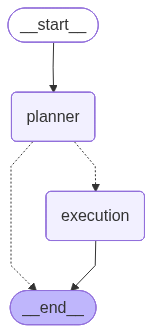



You are a SQL agent planner.
Your job is to generate a high-level plan of logical operations to perform 
on the tables of a database to to answer the user questions. 
Use the information available in the catalog as the truth on tables and their schemas.
The plan must be agent-friendly as it will be consumed by an sql agent 

Workflow:
You must:

1. Analyze the user question and the information in the database catalog

2. Refine the user query into an agent-friendly (refined_query) query that highlights the intent (correct typos,etc). 

3. Produce a step-by-step PLAN 
   The PLAN must contain no SQL and no tool calls.

- Only tables and columns explicitly listed in catalog exist.
- Never invent tables or columns.
- The PLAN must include:
    - source tables
    - target table names
    - whether any existing derived tables can be reused
    - execution order
    - one short line of logic per target table
- If multiple output tables are required:
    - those must be generated sequentia

{'user_query': 'Create two separate tables: one ranking injector wells by total water injection volume, and another ranking producer wells by total oil production volume.',
 'plan': ExecutionPlan(user_query='Create two separate tables: one ranking injector wells by total water injection volume, and another ranking producer wells by total oil production volume.', refined_query='Generate two tables: one ranking injector wells by their total water injection volume, and another ranking producer wells by their total oil production volume.', tables_needed=['injectors', 'producers'], steps=[PlanStep(step_id=1, target_table='injector_wells_ranked_by_water_injection', source_tables=['injectors'], reusable_tables=[], logic='Aggregate total water injection volume for each injector well and rank them in descending order.'), PlanStep(step_id=2, target_table='producer_wells_ranked_by_oil_production', source_tables=['producers'], reusable_tables=[], logic='Aggregate total oil production volume for ea

In [51]:

graph = analyst.as_graph() 
display( graph )

# Direct graph invoke
# =========================================================
result = graph.invoke(
    DataAnalystState(
        user_query=(
            "Create two separate tables: "
            "one ranking injector wells by total water injection volume, "
            "and another ranking producer wells by total oil production volume."
        )
    )
)

result


In [52]:

# =========================================================
# Simple invoke test
# =========================================================
response = analyst.run(
    "Create two separate tables: "
    "one ranking injector wells by total water injection volume, "
    "and another ranking producer wells by total oil production volume."
)

print("FINAL RESPONSE:")
#print(response)





You are a SQL agent planner.
Your job is to generate a high-level plan of logical operations to perform 
on the tables of a database to to answer the user questions. 
Use the information available in the catalog as the truth on tables and their schemas.
The plan must be agent-friendly as it will be consumed by an sql agent 

Workflow:
You must:

1. Analyze the user question and the information in the database catalog

2. Refine the user query into an agent-friendly (refined_query) query that highlights the intent (correct typos,etc). 

3. Produce a step-by-step PLAN 
   The PLAN must contain no SQL and no tool calls.

- Only tables and columns explicitly listed in catalog exist.
- Never invent tables or columns.
- The PLAN must include:
    - source tables
    - target table names
    - whether any existing derived tables can be reused
    - execution order
    - one short line of logic per target table
- If multiple output tables are required:
    - those must be generated sequentia

In [53]:
if response.plan:
    print("\nPLAN:")
    print(response.plan.model_dump_json(indent=3))


if response.execution_result:#" in response:
    print("\nEXECUTION RESULT:")
    print(response.execution_result.model_dump_json(indent=3))


PLAN:
{
   "user_query": "Create two separate tables: one ranking injector wells by total water injection volume, and another ranking producer wells by total oil production volume.",
   "refined_query": "Generate two tables: one ranking injector wells by total water injection volume, and another ranking producer wells by total oil production volume.",
   "tables_needed": [
      "injectors",
      "producers"
   ],
   "steps": [
      {
         "step_id": 1,
         "target_table": "injector_wells_ranked_by_water_injection",
         "source_tables": [
            "injectors"
         ],
         "reusable_tables": [
            "injector_wells_ranked_by_water_injection"
         ],
         "logic": "Aggregate total water injection volume per injector well, rank them in descending order, and store the results."
      },
      {
         "step_id": 2,
         "target_table": "producer_wells_ranked_by_oil_production",
         "source_tables": [
            "producers"
         ],
 

In [58]:
response.execution_result.tables

[TableItemAgentResponse(table_name='injector_wells_ranked_by_water_injection', description='Table ranking injector wells by their total water injection volume in descending order. Includes injector well name, total water injection volume, and rank.'),
 TableItemAgentResponse(table_name='producer_wells_ranked_by_oil_production', description='Table ranking producer wells by their total oil production volume in descending order. Includes producer well name, total oil production volume, and rank.')]

In [ ]:

executor_prompt = executor_prompt_builder(idiom, idiom_rules,plan)

agent = create_agent(
        model=llm,
        system_prompt=executor_prompt,
        tools=tools,
        #response_format=AgentTableResponse,
        #checkpointer= InMemorySaver() 
    )
 
try:
    response = run_agent_stream_values(agent, {} ) 
    last_response = response 
except Exception as e:
    print("STREAM FAILED:", str(e))


In [ ]:
tools

In [ ]:




class old:     

    def fdgdfgrun( self, user_query):

        llm = self._llm
        #planner
        planner_prompt = self._planner_prompt_builder()
        messages = [{
            "role": "system",
            "content": planner_prompt
            },
            {
            "role": "user",
            "content": user_query
            }]
        structured_llm = llm.with_structured_output(ExecutionPlan)

        plan = structured_llm.invoke(messages)
        print('Plan result')
        print( plan )
        
        executor_prompt = self._executor_prompt_builder(self._idiom, 
                                                        self._idiom_rules, 
                                                        plan )  
        executor_agent = create_agent(
                model=llm,
                system_prompt=executor_prompt,
                tools=self._tools,
                #response_format=AgentTableResponse,
                #checkpointer= InMemorySaver() 
            )   
         
        

        #executor 
        try:
            response = run_agent_stream_values(executor_agent, {} ) 
            last_response = response 
        except Exception as e:
            print("STREAM FAILED:", str(e))





    def xxrun(self, user_query: str) -> Dict[str, Any]:

        initial_state: DataAnalystState = {
            "user_query": user_query,
            "plan": None,
            "execution_result": None,
            "error": None,
        }

        return self._graph.invoke(initial_state)    
    
    def planner_node(self,state: DataAnalystState) -> DataAnalystState:
        
        llm = self._llm
        
        # Structured planner
        structured_planner = llm.with_structured_output(ExecutionPlan)
        state["error"] = "" 
        try:
            planner_prompt = self._planner_prompt_builder()
            instruction = state['user_query']
            messages = [
                {
                    "role": "system",
                    "content": planner_prompt
                },
                {
                    "role": "user",
                    "content": instruction
                }
            ]

                
            
            plan = structured_planner.invoke(messages)
            
            state["plan"] = plan
            print("Plan produced")

        except Exception as e:
            state["error"] = f"Planner failed: {str(e)}"

        return state

    def executor_node(self,state: DataAnalystState) -> DataAnalystState:

        llm = self._llm
        if state.get("error"):
            return state

        try:
            plan = state["plan"]
            executor_system_prompt = self._executor_prompt_builder(self._idiom, 
                                                                   self._idiom_rules, 
                                                                   plan)
            
            executor_agent = create_agent(
                model=llm,
                system_prompt=executor_system_prompt,
                tools=self._tools,
                #response_format=AgentTableResponse,
                #checkpointer= InMemorySaver() 
            )     
            
            
            result = executor_agent.invoke({
                "messages": [
                    {
                        "role": "system",
                        "content": executor_system_prompt
                    }

                ]
            })

            state["execution_result"] = result

        except Exception as e:
            state["execution_result"] = None 
            state["error"] = f"Executor failed: {str(e)}"

        return state







        return state 

    def _build_graph(self):

        builder = StateGraph(DataAnalystState)

        builder.add_node("planner", self.planner_node)
        builder.add_node("executor", self.executor_node)

        builder.set_entry_point("planner")

        builder.add_conditional_edges(
            "planner",
            self._should_continue,
            {
                "executor": "executor",
                "end": END,
            }
        )

        builder.add_edge("executor", END)

        return builder.compile()

    def _should_continue(
        self,
        state: DataAnalystState
    ) -> str:

        if state.get("error"):
            return "end"

        return "executor"
    
    def _planner_prompt_builder( self )->str:
        txt = self._data.catalog_snapshot()
        txt = json.dumps( self._data.catalog_snapshot(), indent=3)

        prompt = system_prompt_sql_planner_template.format(catalog=txt)

        return prompt 

    def _executor_prompt_builder( self, idiom, idiom_examples, plan )->str:
        prompt = system_prompt_sql_executor_template.format(idiom=idiom, idiom_examples=idiom_examples, plan=plan)
        return prompt 



        





{
  "base_tables": [
    {
      "name": "injectors",
      "description": "Injector water injection time series.",
      "kind": "base",
      "row_count": 490,
      "columns": [
        {
          "name": "DATE",
          "data_type": "timestamp",
          "description": "Injection date."
        },
        {
          "name": "NAME",
          "data_type": "string",
          "description": "Injector well identifier."
        },
        {
          "name": "WATER_INJECTION_VOLUME",
          "data_type": "float",
          "description": "Injected water volume."
        },
        {
          "name": "SUBZONE",
          "data_type": "string",
          "description": "Vertical subzone."
        },
        {
          "name": "SECTOR",
          "data_type": "integer",
          "description": "Geographic sector."
        },
        {
          "name": "YEAR",
          "data_type": "integer",
          "description": "Year from DATE."
        },
        {
          "name": "MON

In [ ]:
analyst.run( query9 )


In [ ]:
display(analyst._graph )


In [ ]:
for n,item in enumerate(queries):

    print("\n\n")
    print(120*'=')
    user_query = item[0]
    print( user_query, 30*' ', n  )
    print(120*'=')
    

    #user_query = "name the first tree wells in the last table"
    messages = {"messages": [{"role": "user", "content": user_query}]}
    
    try:
        response = run_agent_stream_values(agent, messages ) 
        last_response = response 
    except Exception as e:
        print("STREAM FAILED:", str(e))
    #response = agent.invoke(
    #messages,
    #config={"recursion_limit": 10},
    #)
    print(50*'=',sep="\n\n")
    break